# Week 5 — Classification Lab

**Artificial Intelligence (UGIV) — Semester 2**

**Instructor:** Yassin Hussein Rassul

---

## What you will learn today

1. The difference between **regression** (predicting numbers) and **classification** (predicting categories).
2. How to train **Logistic Regression** to classify students as Pass/Fail.
3. How to train **k-Nearest Neighbors (k-NN)**.
4. How to evaluate classifiers using **accuracy**, **confusion matrix**, **precision**, and **recall**.
5. How to compare two classifiers and decide which one is better.

**Pass mark in this lab:** grade >= 60.

## Section 0 — Setup

We only need **scikit-learn** and **matplotlib**. If they are not installed, run the cell below.

In [1]:
# Install required packages (only run once)
!pip install scikit-learn matplotlib numpy

In [2]:
# Import everything we need
import numpy as np
import matplotlib.pyplot as plt

# Model types
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Tools for training and evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

print('All libraries imported.')

All libraries imported.


## Section 1 — Recap: Regression (Week 4)

Last week we predicted a **number** (the student's grade) from study hours.

This week we will use the **same data**, but ask a different question:

> *Will the student pass or fail?*

This is a **classification** problem because the answer is a category (Pass / Fail), not a number.

## Section 2 — Our Dataset

We have 10 students. For each one we know:
- How many **hours** they studied
- Their **final grade**

A student **passes** if their grade is **60 or higher**.

In [3]:
# Study hours for 10 students
hours = [1, 2, 2, 3, 4, 5, 6, 7, 8, 9]

# Their final grades (0 to 100)
grades = [40, 45, 50, 55, 62, 68, 75, 80, 85, 92]

# Show the data in a simple table
print('Hours | Grade | Pass?')
print('------|-------|------')
for i in range(len(hours)):
    passed = 'Yes' if grades[i] >= 60 else 'No'
    print(hours[i], '    |', grades[i], '   |', passed)

Hours | Grade | Pass?
------|-------|------
1     | 40    | No
2     | 45    | No
2     | 50    | No
3     | 55    | No
4     | 62    | Yes
5     | 68    | Yes
6     | 75    | Yes
7     | 80    | Yes
8     | 85    | Yes
9     | 92    | Yes


### Turning Grades into Labels

We need to convert grades into **0 (Fail)** or **1 (Pass)**.

Machine learning models work with numbers, not words.

In [4]:
# Create the label list: 1 if pass, 0 if fail
labels = []
for g in grades:
    if g >= 60:
        labels.append(1)   # Pass
    else:
        labels.append(0)   # Fail

print('Grades:', grades)
print('Labels:', labels)
# Expected: [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]

Grades: [40, 45, 50, 55, 62, 68, 75, 80, 85, 92]
Labels: [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]


### Preparing the Data for sklearn

scikit-learn expects the features (X) as a **2D array** and the labels (y) as a **1D array**.

In [5]:
# X must be a 2D array — each row is one student, each column is one feature
X = np.array(hours).reshape(-1, 1)

# y is a simple list of labels
y = np.array(labels)

print('Shape of X:', X.shape)   # (10, 1) — 10 students, 1 feature
print('Shape of y:', y.shape)   # (10,)

Shape of X: (10, 1)
Shape of y: (10,)


## Section 3 — Train / Test Split

We split the data into **training** (to teach the model) and **testing** (to check how good it is).

Typical split: **70% train, 30% test**.

In [6]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,      # 30% for testing
    random_state=42     # fixed seed so results are repeatable
)

print('Training set size:', len(X_train))
print('Testing set size:', len(X_test))

Training set size: 7
Testing set size: 3


## Section 4 — Classifier 1: Logistic Regression

Logistic Regression gives us the **probability** that a student will pass.

If probability > 50%, we predict **Pass**. Otherwise **Fail**.

In [7]:
# Create the model
log_model = LogisticRegression()

# Train the model on the training data
log_model.fit(X_train, y_train)

print('Logistic Regression model trained.')

Logistic Regression model trained.


In [8]:
# Predict labels for the test set
log_predictions = log_model.predict(X_test)

print('Test hours:', X_test.flatten())
print('Predicted labels:', log_predictions)

Test hours: [8 2 5]
Predicted labels: [1 0 1]


In [9]:
# Probability that each test student passes
probabilities = log_model.predict_proba(X_test)

print('Hours | P(Fail) | P(Pass)')
print('------|---------|--------')
for i in range(len(X_test)):
    h = X_test[i][0]
    p_fail = round(probabilities[i][0], 2)
    p_pass = round(probabilities[i][1], 2)
    print(h, '    |', p_fail, '   |', p_pass)

Hours | P(Fail) | P(Pass)
------|---------|--------
8     | 0.01    | 0.99
2     | 0.85    | 0.15
5     | 0.2    | 0.8


### Predict for a New Student

What if a student studies for 3.5 hours? Will they pass?

In [10]:
# Predict for 3.5 hours of study
new_student = [[3.5]]
prediction = log_model.predict(new_student)
probability = log_model.predict_proba(new_student)

print('Hours studied: 3.5')
print('Prediction:', prediction[0], '(0 = Fail, 1 = Pass)')
print('Probability of passing:', round(probability[0][1], 2))

Hours studied: 3.5
Prediction: 0 (0 = Fail, 1 = Pass)
Probability of passing: 0.45


### Exercise 1 — Your Turn

Predict whether a student who studied **6.5 hours** will pass.

Also print the probability of passing. Fill in the blanks.

In [11]:
# Your turn — fill in the blanks
# new_student = [[ _____ ]]
# prediction = log_model.predict( _____ )
# probability = log_model.predict_proba( _____ )

# print('Prediction:', prediction[0])
# print('Probability of passing:', round(probability[0][1], 2))

## Section 5 — Classifier 2: k-Nearest Neighbors (k-NN)

k-NN predicts by looking at the **k closest** students in the training data and voting.

We will use **k = 3**.

In [12]:
# Create the model (k = 3 neighbors)
knn_model = KNeighborsClassifier(n_neighbors=3)

# Train it on the same training data
knn_model.fit(X_train, y_train)

print('k-NN model trained (k = 3).')

k-NN model trained (k = 3).


In [13]:
# Predict labels for the test set
knn_predictions = knn_model.predict(X_test)

print('Test hours:', X_test.flatten())
print('True labels     :', y_test)
print('Predicted labels:', knn_predictions)

Test hours: [8 2 5]
True labels     : [1 0 1]
Predicted labels: [1 0 1]


### Exercise 2 — Try a Different k

Create a new k-NN model with **k = 5**. Train it and print the predictions.

In [14]:
# Your turn — fill in the blanks
# knn_model_5 = KNeighborsClassifier(n_neighbors= _____ )
# knn_model_5.fit( _____ , _____ )
# predictions_5 = knn_model_5.predict(X_test)

# print('Predictions with k=5:', predictions_5)

## Section 6 — Evaluating the Models

Now we compare the two models. We use 4 metrics:

- **Accuracy** — % of correct predictions
- **Confusion matrix** — table of right/wrong predictions
- **Precision** — of predicted Pass, how many were really Pass
- **Recall** — of real Pass, how many did we catch

### Accuracy

In [15]:
# Accuracy of Logistic Regression
log_accuracy = accuracy_score(y_test, log_predictions)

# Accuracy of k-NN
knn_accuracy = accuracy_score(y_test, knn_predictions)

print('Logistic Regression accuracy:', round(log_accuracy, 2))
print('k-NN accuracy              :', round(knn_accuracy, 2))

Logistic Regression accuracy: 1.0
k-NN accuracy              : 1.0


### Confusion Matrix

The matrix tells us:

|              | Predicted Fail | Predicted Pass |
|--------------|----------------|----------------|
| Actual Fail  |    TN          |    FP          |
| Actual Pass  |    FN          |    TP          |

In [16]:
# Confusion matrix for Logistic Regression
log_cm = confusion_matrix(y_test, log_predictions)
print('Logistic Regression confusion matrix:')
print(log_cm)
print()

# Confusion matrix for k-NN
knn_cm = confusion_matrix(y_test, knn_predictions)
print('k-NN confusion matrix:')
print(knn_cm)

Logistic Regression confusion matrix:
[[1 0]
 [0 2]]

k-NN confusion matrix:
[[1 0]
 [0 2]]


### Precision and Recall

In [17]:
# Precision and Recall for Logistic Regression
log_precision = precision_score(y_test, log_predictions, zero_division=0)
log_recall = recall_score(y_test, log_predictions, zero_division=0)

# Precision and Recall for k-NN
knn_precision = precision_score(y_test, knn_predictions, zero_division=0)
knn_recall = recall_score(y_test, knn_predictions, zero_division=0)

print('Logistic Regression -> Precision:', round(log_precision, 2), '  Recall:', round(log_recall, 2))
print('k-NN                -> Precision:', round(knn_precision, 2), '  Recall:', round(knn_recall, 2))

Logistic Regression -> Precision: 1.0   Recall: 1.0
k-NN                -> Precision: 1.0   Recall: 1.0


### Exercise 3 — Compare the Two Models

Look at the numbers above and answer (in a comment or print statement):

1. Which model has higher accuracy?
2. Which model has higher precision?
3. Which model would you trust more for this problem? Why?

In [18]:
# Write your answer here as comments or print statements
# 1. Highest accuracy: _____
# 2. Highest precision: _____
# 3. I would trust _____ more because _____


## Section 7 — Visualizing the Decision

We plot the training points and the logistic regression S-curve to see what the model learned.

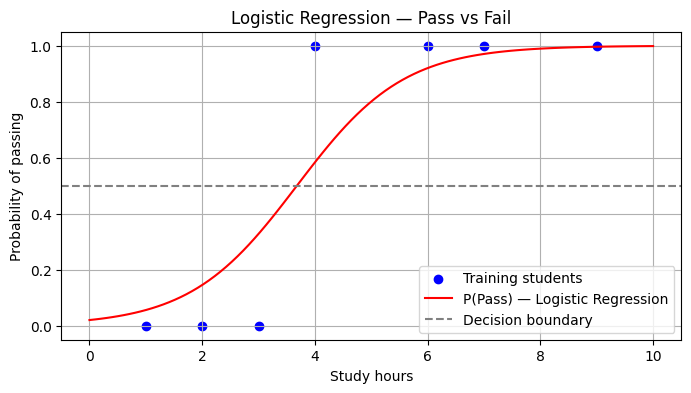

In [19]:
# Create a smooth range of hours from 0 to 10
hours_range = np.linspace(0, 10, 100).reshape(-1, 1)

# Get the probability of passing for each value in the range
prob_pass = log_model.predict_proba(hours_range)[:, 1]

# Plot the training points
plt.figure(figsize=(8, 4))
plt.scatter(X_train, y_train, color='blue', label='Training students')

# Plot the S-curve
plt.plot(hours_range, prob_pass, color='red', label='P(Pass) — Logistic Regression')

# Plot the decision line at 0.5
plt.axhline(y=0.5, color='gray', linestyle='--', label='Decision boundary')

plt.xlabel('Study hours')
plt.ylabel('Probability of passing')
plt.title('Logistic Regression — Pass vs Fail')
plt.legend()
plt.grid(True)
plt.show()

## Section 8 — Challenge: A Bigger Dataset

Let's try both models on a slightly bigger dataset (20 students) and see what happens.

In [20]:
# A bigger dataset — 20 students
hours_big = [1, 1.5, 2, 2, 2.5, 3, 3, 3.5, 4, 4.5,
             5, 5, 5.5, 6, 6, 7, 7.5, 8, 8.5, 9]

grades_big = [35, 40, 42, 48, 52, 55, 58, 60, 62, 65,
              68, 70, 72, 75, 78, 80, 82, 85, 88, 92]

# Build labels
labels_big = []
for g in grades_big:
    if g >= 60:
        labels_big.append(1)
    else:
        labels_big.append(0)

# Shape the data
X_big = np.array(hours_big).reshape(-1, 1)
y_big = np.array(labels_big)

print('Total students:', len(X_big))
print('Labels        :', y_big)

Total students: 20
Labels        : [0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1]


### Exercise 4 — Full Pipeline

Using the bigger dataset (`X_big`, `y_big`), do all of these:

1. Split into train and test (70 / 30).
2. Train a Logistic Regression model and a k-NN model (k=3).
3. Print the accuracy of both.
4. Print the confusion matrix of the better one.

Fill in the blanks below.

In [21]:
# Step 1 — split the data
# X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
#     _____ , _____ , test_size= _____ , random_state=42
# )

# Step 2 — train both models
# log_big = LogisticRegression()
# log_big.fit( _____ , _____ )

# knn_big = KNeighborsClassifier(n_neighbors= _____ )
# knn_big.fit( _____ , _____ )

# Step 3 — accuracy
# log_acc = accuracy_score(y_test_b, log_big.predict(X_test_b))
# knn_acc = accuracy_score(y_test_b, knn_big.predict(X_test_b))
# print('Logistic accuracy:', log_acc)
# print('k-NN accuracy    :', knn_acc)

# Step 4 — confusion matrix of the better model
# print(confusion_matrix( _____ , _____ ))


## Takeaways

By the end of this lab you should understand:

1. **Classification** predicts a category (Pass / Fail), not a number.
2. **Logistic Regression** gives the probability of belonging to a class using an S-curve.
3. **k-NN** classifies by voting among the k nearest neighbors.
4. **Accuracy alone is not enough** — always check the confusion matrix, precision, and recall.
5. The **right metric** depends on the real-world cost of mistakes (spam vs cancer detection).

## Next Week

**Week 6 — Unsupervised Learning I (Clustering)**

No more labels! We will let the model find patterns on its own using **k-means**.